# **Notebook 2: Data Preprocessing & Merging**

> **Objective:** Transform raw customer demographics and transactional basket data into a unified, model-ready master dataset. Heavy lifting and pipeline steps are modularly executed via our centralized `datacleaning.py` script.

---

## **Table of Contents**
1. [Imports and Libraries](#1-imports)
2. [Load Raw Datasets](#2-load)
3. [Execute Independent Cleaning Pipelines](#3-pipelines)
4. [Merging the Two Clean Datasets (Inner Join)](#4-merge)
5. [Validation Checks](#5-validation)
6. [Export Final Data](#6-export)

---


<a id="1-imports"></a>
## **1. Imports and Libraries**

In [1]:
# to import from src folder (where our py files are located)
import sys 
sys.path.append("../src") 

# functions to clean the raw data
from datacleaning import customer_clean_data , basket_clean_data , check_missing, check_datatypes, check_numeric_ranges, merge_datasets, plot_dbscan_clusters_with_outliers

# to check the current working directory                      
import os 
os.getcwd()

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# to automatically reload the py files when they are edited
%load_ext autoreload
%autoreload 2

# to ignore warnings
import warnings
warnings.filterwarnings('ignore')

<a id="2-load"></a>
## **2. Load Raw Datasets**

> We import the 2 raw CSV files.

It is crucial to **understand the differences** between our two primary data sources before manipulating them:
- The `customer_info` dataset is a database where **each row represents a unique individual**. Therefore, we set the **customer ID** directly as the dataframe **index** to ensure data integrity.
- The `customer_basket` dataset is a transactional log of **receipts**. A single customer can have multiple rows (representing multiple trips to the store). Thus, we load it **without** a fixed index, which allows our pipeline to properly group and aggregate the transactions later.

In [2]:
raw_data_customer = pd.read_csv('../data/customer_info.csv', index_col=0) #customer id as index
raw_data_basket = pd.read_csv('../data/customer_basket.csv')

print(f"Raw customer dataset shape: {raw_data_customer.shape}") 
print(f"Raw basket dataset shape: {raw_data_basket.shape}")

Raw customer dataset shape: (33038, 24)
Raw basket dataset shape: (100000, 3)


In [3]:
raw_data_customer.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33038 entries, 3 to 40000
Data columns (total 24 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_name                            33038 non-null  object 
 1   customer_gender                          33038 non-null  object 
 2   customer_birthdate                       32873 non-null  object 
 3   kids_home                                32708 non-null  float64
 4   teens_home                               32708 non-null  float64
 5   number_complaints                        32377 non-null  float64
 6   distinct_stores_visited                  32708 non-null  float64
 7   lifetime_spend_groceries                 33038 non-null  float64
 8   lifetime_spend_electronics               32377 non-null  float64
 9   typical_hour                             32377 non-null  float64
 10  lifetime_spend_vegetables                32377 non-

<a id="3-pipelines"></a>
## **3. Execute Independent Cleaning Pipelines**
> We run both datasets through their preprocessing **pipelines** pre-defined in our `datacleaning.py` file. These pipelines automatically correct data types, drop impossible values, handle missing values (using advanced KNN Imputation) and perform feature engineering (such as calculating customer's ages and another useful variables).

Our pipeline is divided into **two separate flows** that treat the specific needs of each dataset before they are merged:

#### **A. Customer Info (`customer_clean_data`)**

1. **Data Types:** We convert date strings into datetime objects, floats into integers and calculate `customer_age` based on the birthdate;
2. **Impossible Values:** We "created" some strict rules. Ages must be between 1 and 120, the `typical_hour` of shopping must be during store hours (6 to 23) and count/spend variables cannot be negative. Any violations are temporarily converted to `NaN`.
3. **Missing Values:** 
   * **Zero-filling:** Missing values in the `lifetime_spend` columns are filled with 0, assuming the customer simply hasn't bought from that category.
   * **KNN Imputation (k=7):** For the other missing values, we use a K-Nearest Neighbors imputer.
4. **Outliers:** We apply **DBSCAN** with `eps=4.5` and `min_samples=10` that automatically identifies and drops severe multidimensional outliers.
5. **Feature Engineering:** We create new analytical features:
   * `education_level`: Extracted directly from the customer's title (Bsc, Msc, Phd). Unknown when there's no information.
   * `total_children` & `has_children`: Aggregated from the kids and teens columns.
   * `time_of_day`: Categorized based on the typical hour.



#### **B. Customer Basket(`basket_clean_data`)**
1. **Data Parsing:** The `list_of_goods` comes in as a string. We use `ast.literal_eval` to convert these back into iterable Python objects.
2. **Feature Extraction:** We calculate the `basket_size` (number of items) for every single receipt.
3. **Aggregations:** Since the raw data has one row per receipt, we group the data by `customer_id` so it matches our Customer dataset. We aggregate the transactions to find:
   * `total_trips` (Number of unique invoices)
   * `total_items_bought` & `average_basket_size`
   * `unique_products_bought`
4. **Outlier Detection:** We run a second, tighter DBSCAN (`eps=1.5`, `min_samples=15`) specifically on the shopping behavior metrics to remove extreme bulk buyers.

--

In [4]:
# Run the complete cleaning pipeline
clean_customer_df = customer_clean_data(raw_data_customer)
clean_basket_df = basket_clean_data(raw_data_basket)

print(f"Cleaned customer dataset shape: {clean_customer_df.shape}")
print(f"Cleaned basket dataset shape: {clean_basket_df.shape}")

Cleaned customer dataset shape: (33005, 37)
Cleaned basket dataset shape: (28124, 7)


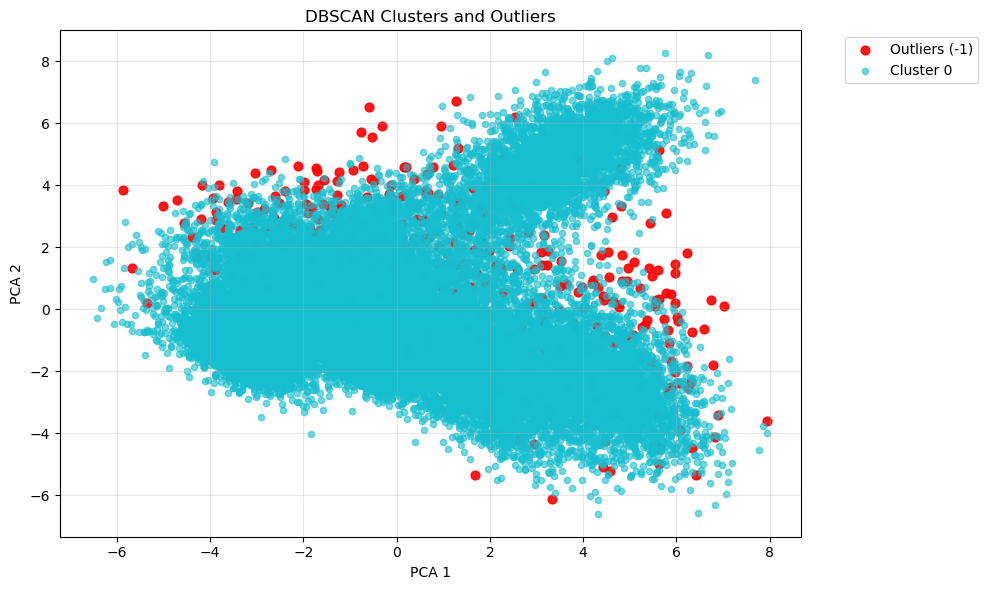

In [5]:
clean_customer_numeric = clean_customer_df.select_dtypes(include='number')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(clean_customer_numeric)

dbscan = DBSCAN(eps=4.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)

plot_dbscan_clusters_with_outliers(X_scaled, dbscan_labels)

In [6]:
clean_customer_df.to_csv('../data/clean_customer_info.csv', index=True)

#### **Observed Changes**
As we can see from the outputs above, our pipeline successfully:
1. Shrank the customer dataset from **33,038** to **32,269** rows (mainly due to the removal of DBSCAN outliers).
2. Aggregated the **100,000** transactions into **28,124** unique customer profiles.

In the next step, we will run some validation checks to definitively prove that our pipeline resolved all missing values and successfully followed our logical constraints.

<a id="4-merge"></a>
## **4. Merging the Two Clean Datasets (Inner Join)**

> In this section, we will combine the cleaned customer dataset with the aggregated transaction dataset using an **Inner Join**.

#### **Why Inner Join?**

We used this type of join to ensure that only customers with **complete information in both datasets** are included in the final analysis. We noticed many customers were only registred in one of them. This approach:

1. **Removes noise:** Eliminates customers with missing transaction history or incomplete profile data;
2. **Ensures consistency:** Only rows with matching IDs across both datasets are retained;
3. **Improves quality:** Prevents biased analyses caused by misaligned or incomplete data;
4. **Aligns with business logic:** We are only interested in customers with registered purchasing behavior.

In [7]:
final_df = merge_datasets(clean_customer_df, clean_basket_df)
print(f'Final Dataset Shape:{final_df.shape}')
final_df.head()

Final Dataset Shape:(33005, 44)


,customer_id,customer_name,customer_gender,customer_age,education_level,kids_home,teens_home,total_children,year_first_transaction,years_tenure,...,perc_spend_alcohol,perc_spend_hygiene,latitude,longitude,total_trips,total_items_bought,average_basket_size,max_basket_size,min_basket_size,unique_products_bought
0,3,Crystal Kitchens,female,56,Bsc,1,1,2,2020,6,...,0.009521,0.029693,38.794428,-9.215739,2.0,21.0,10.5,11.0,10.0,21.0
1,4,Glenda Bauman,female,51,Bsc,1,0,1,2013,13,...,0.004695,0.092918,38.751711,-9.179611,2.0,24.0,12.0,12.0,12.0,20.0
2,5,Antonio Campbell,male,55,Msc,0,0,0,2005,21,...,0.007589,0.032607,38.780678,-9.160656,1.0,8.0,8.0,8.0,8.0,8.0
3,7,John Kelling,male,44,Unknown,0,0,0,2021,5,...,0.075776,0.032437,38.739548,-9.148679,1.0,4.0,4.0,4.0,4.0,4.0
4,8,Arthur Dematteo,male,57,Unknown,0,0,0,2021,5,...,0.027833,0.011513,38.733071,-9.188188,NaN,NaN,NaN,NaN,NaN,NaN


We are left with a complete analysis of **27475 different customers**.

<a id="5-validation"></a>
## **5. Validation Checks**

> We will now perform **validation checks** on our final dataset to verify **both pipelines were executed sucessfully.** Missing Values, Data types and our Logical Rules will be verified

#### **Check 1: Missing Values**

In [8]:
check_missing(final_df, raw_data_customer, raw_data_basket)

,Missing Count (Final),Missing Count (Original)
customer_birthdate,NaN,165.0
distinct_stores_visited,0.0,330.0
kids_home,0.0,330.0
lifetime_spend_alcohol_drinks,0.0,330.0
lifetime_spend_electronics,0.0,661.0
lifetime_spend_fish,0.0,991.0
lifetime_spend_hygiene,0.0,330.0
lifetime_spend_meat,0.0,661.0
lifetime_spend_petfood,0.0,661.0
lifetime_spend_vegetables,0.0,661.0


We verify that the data cleaning pipeline has successfully resolved all missing values. A complete dataset 
with no null values is essential for machine learning models, as most algorithms cannot handle missing data 
without additional imputation strategies.

#### **Check 2: Data Types**

In [9]:
# Verifies that columns are ordered nicely and types are correct (Int64, float64, etc.)
check_datatypes(final_df, raw_data_customer, raw_data_basket)

,Datatype (Final),Datatype (Original)
average_basket_size,float64,NaN
customer_age,Int64,NaN
customer_birthdate,NaN,object
distinct_stores_visited,Int64,float64
education_level,object,NaN
invoice_id,NaN,int64
kids_home,Int64,float64
lifetime_spend_electronics_videogames,float64,NaN
lifetime_spend_meat_fish,float64,NaN
lifetime_total_distinct_products,Int64,float64


#### **Check 3: Logical Constraints**

In [10]:
check_numeric_ranges(final_df)

,customer_age,typical_hour,percentage_of_products_bought_promotion,total_children,year_first_transaction,number_complaints,distinct_stores_visited,lifetime_spend_groceries,total_trips,average_basket_size
min,24.0,6.0,0.0,0.0,1993.0,0.0,1.0,0.0,1.0,2.0
max,86.0,23.0,1.0,14.0,2026.0,7.0,10.0,101806.0,25.0,18.0


<a id="6-export"></a>
## **6. Export Final Data**

> Our final dataset is now oficially ready to be used in **Notebook 3: Modelling**

In [11]:
final_df.to_csv('../data/final_dataset.csv', index=True)